<a href="https://colab.research.google.com/github/taleleyukta-stack/CodeAlpha_ML_Internship/blob/main/CodeAlpha_Task_1_CreditScoring_yukta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (1000, 21)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.775
Random Forest Accuracy: 0.805

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.53      0.61        59
           1       0.82      0.92      0.87       141

    accuracy                           0.81       200
   macro avg       0.78      0.72      0.74       200
weighted avg       0.80      0.81      0.79       200



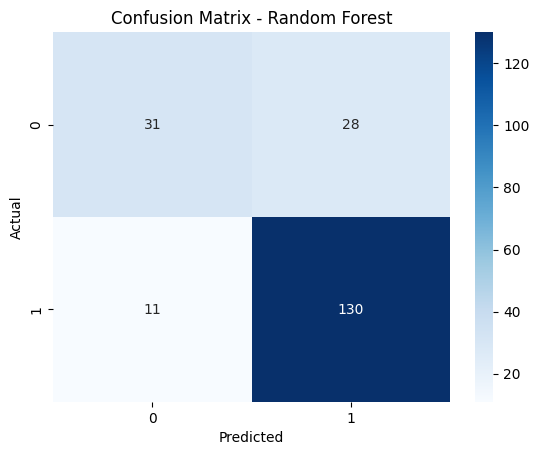

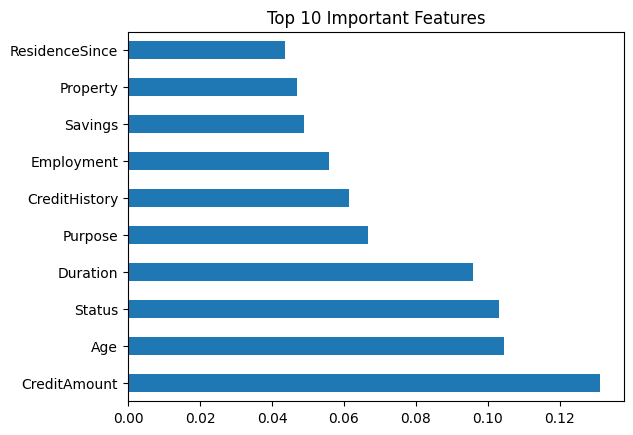

In [8]:
# Task 1: Credit Scoring Model - Code Alpha ML Internship
# Student: Yukta | ID: CA/DF1/182643

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/german.csv"
cols = ['Status','Duration','CreditHistory','Purpose','CreditAmount','Savings','Employment',
        'InstallmentRate','PersonalStatus','OtherDebtors','ResidenceSince','Property','Age',
        'OtherInstallment','Housing','ExistingCredits','Job','NumDependents','Telephone',
        'ForeignWorker','Target']
df = pd.read_csv(url, names=cols)
print("Dataset Shape:", df.shape)
df.head()

# 2. Preprocessing
df['Target'] = df['Target'].map({1: 1, 2: 0}) # 1=Good, 0=Bad
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Target', axis=1)
y = df['Target']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# 5. Model 2: Random Forest - Better accuracy
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 7. Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.head(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()